<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Vacuum Diagnostic 1 - Propagation and Flux
---

This notebook is the diagnostic companion to `tpeanuts.medium.vacuum`: the
flavour-basis evolution operator (`medium.vacuum.evolutor`), the oscillation
probabilities built on top of it (`medium.vacuum.probability`), and the flux
wrapper (`medium.vacuum.flux`).

The notebook is intentionally diagnostic rather than a pytest suite. The
automated sanity checks live in `tpeanuts.medium.vacuum.test.test1_evolutor`,
`test2_probability`, and `test3_flux`; here we keep the plots and physical
interpretation. Section 10 also demonstrates a real finding from building that
pytest suite: `peanuts.vacuum.vacuum_evolved_state` (the read-only legacy
reference) has an argument-order bug that `peanuts.vacuum.Pvacuum` does not
share, so the raw complex-amplitude comparison is `xfail` while the
probability-level comparison passes tightly.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: vacuum evolutor, oscillation length, vacuum_probability_state conventions |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Evolutor-Unitarity-and-Scale-Invariance) | **Evolutor Unitarity and Scale Invariance** |
| [4](#4.-Oscillation-Probability-versus-Baseline) | **Oscillation Probability versus Baseline** |
| [5](#5.-Neutrino-versus-Antineutrino-and-the-CP-Phase) | **Neutrino versus Antineutrino and the CP Phase** |
| [6](#6.-Two-Dimensional-L-E-Oscillogram) | **Two-Dimensional L-E Oscillogram** |
| [7](#7.-Transition-Probability-Matrix-Structure) | **Transition Probability Matrix Structure** |
| [8](#8.-CP-Violation-and-the-Jarlskog-Invariant) | **CP Violation and the Jarlskog Invariant** |
| [9](#9.-Vacuum-Flux-from-Probability) | **Vacuum Flux from Probability** |
| [10](#10.-Validation-against-Legacy-Peanuts) | **Validation against Legacy Peanuts** |
| [11](#11.-Summary) | **Summary** |


## 0. Theory Background

### 0.1 The Vacuum Evolution Operator

With no matter potential, the flavour-basis evolution operator over a
baseline $L$ at energy $E$ is exactly

$$
S(L,E) = U\,\mathrm{diag}\bigl(e^{-ik_1x},e^{-ik_2x},e^{-ik_3x}\bigr)\,U^\dagger,
\qquad x=\frac{L\,[\mathrm{m}]}{L_0},
$$

where $U$ is the PMNS matrix, $k_i=L_0\,\Delta m_{i1}^2/(2E\hbar c)$ are the
dimensionless kinetic mass-basis terms (`kinetic_eigenvalue_vector`), and $L_0$ is
an arbitrary bookkeeping length scale (`evolution_scale_m`, `R_E` by default).
Because $k_i\,x$ only depends on the physical ratio $L/E$, $S$ itself does not
depend on the choice of $L_0$ -- Section 3 verifies this directly. $S$ is
exactly unitary for any $L$, $E$: there is no perturbative truncation in
vacuum, unlike the Earth matter-propagation evolutor.

---

### 0.2 Oscillation Length

The oscillation phase for splitting $\Delta m^2_{i1}$ completes a full cycle
over the oscillation length

$$
L_{\rm osc}^{(i1)} \;[\mathrm{km}] \approx 2.48\,\frac{E\,[\mathrm{GeV}]}{\Delta m^2_{i1}\,[\mathrm{eV}^2]}.
$$

At fixed $E$, the fast atmospheric-scale oscillation ($\Delta m^2_{31}$) and
the slow solar-scale oscillation ($\Delta m^2_{21}$) have oscillation lengths
that differ by $\Delta m^2_{31}/\Delta m^2_{21}\sim 34$ for the values used
here, which is why the baseline scan in Section 4 shows fast structure
modulated by a much slower envelope.

---

### 0.3 vacuum_probability_state: Two Input Conventions

`vacuum_probability_state` mirrors the same two conventions used throughout `medium.earth`:

- **Flavour basis** ($\text{massbasis}=\text{False}$): coherent amplitude
  input $\psi_\beta$, evolved as $\psi_f=S\psi_i$ and
  $P_\alpha=|\psi_{f,\alpha}|^2$.
- **Mass basis** ($\text{massbasis}=\text{True}$): incoherent mass-eigenstate
  weights $w_i$, giving $P_\alpha=\sum_i|(SU)_{\alpha i}|^2 w_i$.

At $L=0$, $S=\mathbb{1}$: the flavour-basis result trivially returns the
input flavour, while the mass-basis result reduces to the vacuum PMNS column
$|U_{\alpha 1}|^2$ for $w=(1,0,0)$.

---

### 0.4 Vacuum Flux

`vacuum_flux_state` applies a flux normalization and optional spectral weight on top
of `vacuum_probability_state`, exactly as `earth_flux_state` does on top of `earth_probability_state`:
$\Phi_\alpha = P_\alpha\times\text{flux}\times\text{spectrum}$, with
`flux`/`spectrum` broadcasting against the *leading* (energy/baseline)
dimensions, not the trailing flavour axis.

---

### References

- B. Pontecorvo, "Neutrino experiments and the problem of conservation of
  leptonic charge", *Sov. Phys. JETP* **26**, 984 (1968).
- Z. Maki, M. Nakagawa, S. Sakata, "Remarks on the unified model of elementary
  particles", *Prog. Theor. Phys.* **28**, 870 (1962).
- C. Jarlskog, "Commutator of the quark mass matrices in the standard
  electroweak model and a measure of maximal CP violation", *Phys. Rev. Lett.*
  **55**, 1039 (1985).


## 1. Libraries

In [ ]:
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.common.pmns import PMNSParams
from tpeanuts.core.SM.sm_mass_spectrum import MassSpectrum_SM
from tpeanuts.core.SM.sm_pmns import PMNS_SM
from tpeanuts.medium.vacuum.evolutor import vacuum_evolutor, vacuum_evolved_state
from tpeanuts.medium.vacuum.flux import vacuum_flux_state
from tpeanuts.medium.vacuum.probability import vacuum_probability_state, vacuum_probability_transition
from tpeanuts.medium.vacuum import validation as legacy_validation
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy
from tpeanuts.util.context import RuntimeContext


def make_oscillation(*, theta12, theta13, theta23, delta, DeltamSq21, DeltamSq3l, antinu, context):
    """Build a plain 3-flavour SM OscillationParameters from explicit angles."""
    pmns = PMNS_SM(PMNSParams(theta12=theta12, theta13=theta13, theta23=theta23, delta=delta, context=context))
    mass_spectrum = MassSpectrum_SM(
        DeltamSq21=torch.as_tensor(DeltamSq21, device=context.device, dtype=context.dtype),
        DeltamSq3l=torch.as_tensor(DeltamSq3l, device=context.device, dtype=context.dtype),
    )
    return OscillationParameters(pmns=pmns, mass_spectrum=mass_spectrum, antinu=antinu)


print(f"Torch {torch.__version__}")

## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared
plotting style, and provides the common output root. The output directory is
built from the notebook path relative to `notebooks/`, excluding the notebook
filename: `diagnostic/vacuum`.

**Expected results:** the printed paths should point to the local TPeanuts
repository and to an output directory ending in `diagnostic/vacuum`.

In [ ]:
config = load_notebook_config()
ctx = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("diagnostic", "vacuum")

# The legacy `peanuts` package sits at the repo root and is not on sys.path by
# default inside a Jupyter kernel (unlike `python -m pytest`, which adds it
# automatically). Section 10 needs it for the legacy comparison.
import sys
if str(config.package_dir) not in sys.path:
    sys.path.insert(0, str(config.package_dir))

oscillation = make_oscillation(
    theta12=0.59,
    theta13=0.15,
    theta23=0.78,
    delta=1.20,
    DeltamSq21=7.42e-5,
    DeltamSq3l=2.517e-3,
    antinu=False,
    context=ctx,
)
oscillation_antinu = make_oscillation(
    theta12=0.59, theta13=0.15, theta23=0.78, delta=1.20,
    DeltamSq21=7.42e-5, DeltamSq3l=2.517e-3, antinu=True, context=ctx,
)

FLAVOUR_LABELS = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"]

print(f"Package dir : {config.package_dir}")
print(f"Output dir  : {OUTPUT_DIR}")
print(f"Device      : {ctx.device}   dtype: {ctx.dtype}")
print(f"DeltamSq21  : {float(oscillation.mass_spectrum.DeltamSq21):.4e} eV^2")
print(f"DeltamSq3l  : {float(oscillation.mass_spectrum.DeltamSq3l):.4e} eV^2")

## 3. Evolutor Unitarity and Scale Invariance

`vacuum_evolutor` should be exactly unitary at any $(E,L)$, and the physical
operator should not depend on the bookkeeping scale `evolution_scale_m`.

**Expected results:** the maximum unitarity error should sit at machine
precision; the evolutor computed at three different `evolution_scale_m`
values should be identical to machine precision.

In [14]:
E_scan = torch.tensor([250.0, 1000.0, 3000.0, 10000.0], device=ctx.device, dtype=ctx.dtype)
L_scan = torch.tensor(1300.0, device=ctx.device, dtype=ctx.dtype)

S = vacuum_evolutor(oscillation, E_scan, L_scan, context=ctx)
identity = torch.eye(3, device=ctx.device, dtype=S.dtype)
unitarity_error = torch.amax(torch.abs(S.conj().transpose(-1, -2) @ S - identity), dim=(-2, -1))

S_default = vacuum_evolutor(oscillation, E_scan, L_scan, context=ctx, evolution_scale_m=6.371e6)
S_double = vacuum_evolutor(oscillation, E_scan, L_scan, context=ctx, evolution_scale_m=1.2742e7)
S_small = vacuum_evolutor(oscillation, E_scan, L_scan, context=ctx, evolution_scale_m=6.371e5)
scale_invariance_error = max(
    float(torch.max(torch.abs(S_double - S_default))),
    float(torch.max(torch.abs(S_small - S_default))),
)

print(f"max unitarity error over E scan   : {float(torch.max(unitarity_error)):.3e}")
print(f"max scale-invariance error         : {scale_invariance_error:.3e}")
S_zero = vacuum_evolutor(oscillation, torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype), torch.tensor(0.0, device=ctx.device, dtype=ctx.dtype), context=ctx)
print(f"S(L=0) is identity                 : {bool(torch.allclose(S_zero, torch.eye(3, device=ctx.device, dtype=S_zero.dtype), atol=1e-12))}")

max unitarity error over E scan   : 5.551e-16
max scale-invariance error         : 7.850e-17
S(L=0) is identity                 : True


## 4. Oscillation Probability versus Baseline

`vacuum_probability_state` for a pure initial $\nu_\mu$ state, scanned over baseline at fixed
energy. Vertical lines mark the oscillation lengths of the atmospheric and
solar mass splittings at this energy.

**Expected results:** fast atmospheric-scale oscillations modulated by a much
slower solar-scale envelope; probabilities should stay within $[0,1]$ and sum
to 1 at every baseline.

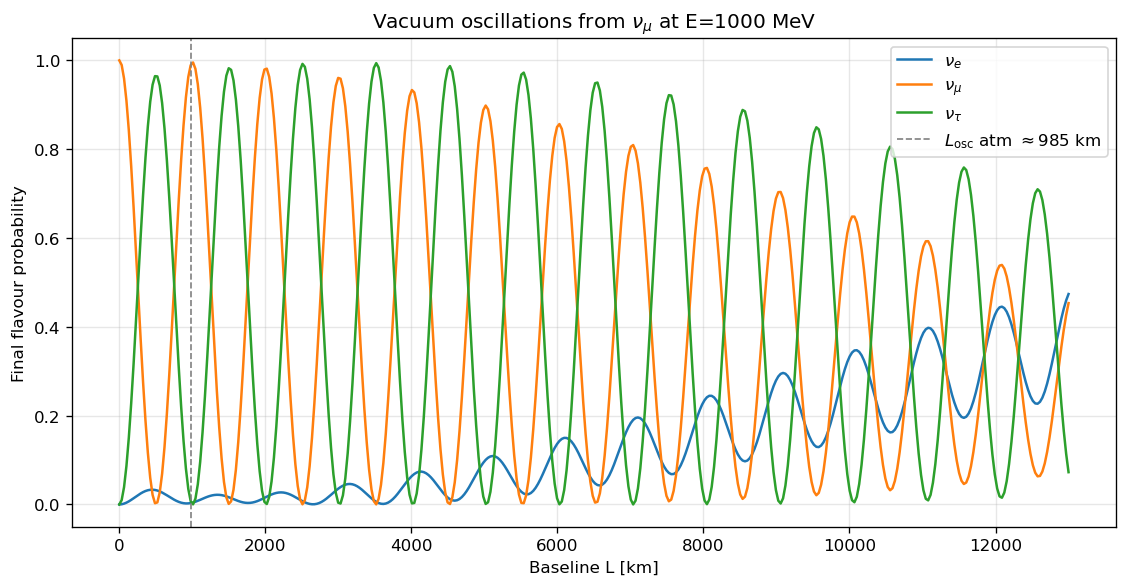

v:\output\diagnostic\vacuum\diagnostic1_fig4_probability_vs_baseline.png
Atmospheric oscillation length at E=1000 MeV: 985.3 km
Solar oscillation length at E=1000 MeV      : 33423.2 km
max |sum_alpha P - 1| over baseline scan: 8.882e-16


In [15]:
E_FIXED = 1000.0
baselines = torch.linspace(0.0, 13000.0, 400, device=ctx.device, dtype=ctx.dtype)
initial_mu = torch.tensor([0.0, 1.0, 0.0], device=ctx.device, dtype=torch.complex128)

P_vs_L = vacuum_probability_state(initial_mu, oscillation, torch.tensor(E_FIXED, device=ctx.device, dtype=ctx.dtype), baselines, massbasis=False, context=ctx)

L_osc_atm = 2.48 * (E_FIXED / 1000.0) / abs(float(oscillation.mass_spectrum.DeltamSq3l))
L_osc_sol = 2.48 * (E_FIXED / 1000.0) / abs(float(oscillation.mass_spectrum.DeltamSq21))

fig, ax = plt.subplots(figsize=(9.5, 5.0))
for idx, label in enumerate(FLAVOUR_LABELS):
    ax.plot(to_numpy(baselines), to_numpy(P_vs_L[:, idx]), label=label)
ax.axvline(L_osc_atm, color="gray", ls="--", lw=1.0, label=rf"$L_{{\rm osc}}$ atm $\approx${L_osc_atm:.0f} km")
ax.set_xlabel("Baseline L [km]")
ax.set_ylabel("Final flavour probability")
ax.set_title(rf"Vacuum oscillations from $\nu_\mu$ at E={E_FIXED:.0f} MeV")
ax.legend()

fig.tight_layout()
save_and_show("diagnostic1_fig4_probability_vs_baseline.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

row_sum_err = float(torch.max(torch.abs(P_vs_L.sum(dim=-1) - 1.0)))
print(f"Atmospheric oscillation length at E={E_FIXED:.0f} MeV: {L_osc_atm:.1f} km")
print(f"Solar oscillation length at E={E_FIXED:.0f} MeV      : {L_osc_sol:.1f} km")
print(f"max |sum_alpha P - 1| over baseline scan: {row_sum_err:.3e}")

## 5. Neutrino versus Antineutrino and the CP Phase

The same $\nu_\mu$ survival/appearance probabilities computed for neutrinos
and antineutrinos (via `oscillation.antinu`), scanned over energy at a fixed
baseline, plus their difference.

**Expected results:** the neutrino and antineutrino curves should differ only
through the CP phase $\delta_{CP}\neq0$; the difference panel should vanish
identically when $\delta_{CP}=0$ (checked numerically below).

In [ ]:
L_FIXED = 1300.0
E_grid = torch.logspace(math.log10(100.0), math.log10(10000.0), 200, device=ctx.device, dtype=ctx.dtype)

P_nu = vacuum_probability_state(initial_mu, oscillation, E_grid, torch.tensor(L_FIXED, device=ctx.device, dtype=ctx.dtype), massbasis=False, context=ctx)
P_anu = vacuum_probability_state(initial_mu, oscillation_antinu, E_grid, torch.tensor(L_FIXED, device=ctx.device, dtype=ctx.dtype), massbasis=False, context=ctx)
diff = P_nu - P_anu

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), sharex=True)
for idx, label in enumerate(FLAVOUR_LABELS):
    axes[0].plot(to_numpy(E_grid), to_numpy(P_nu[:, idx]), label=f"neutrino {label}")
    axes[0].plot(to_numpy(E_grid), to_numpy(P_anu[:, idx]), "--", label=f"antineutrino {label}")
    axes[1].plot(to_numpy(E_grid), to_numpy(diff[:, idx]), label=label)

axes[0].set_xscale("log")
axes[1].set_xscale("log")
axes[0].set_xlabel("Energy [MeV]")
axes[1].set_xlabel("Energy [MeV]")
axes[0].set_ylabel("Final flavour probability")
axes[1].set_ylabel(r"$P(\nu)-P(\bar\nu)$")
axes[0].set_title(rf"Vacuum probabilities at L={L_FIXED:.0f} km")
axes[1].set_title("CP-phase vacuum difference")
axes[0].legend(fontsize=8, ncol=2)
axes[1].legend(fontsize=8)

fig.tight_layout()
save_and_show("diagnostic1_fig5_nu_antinu_comparison.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

oscillation_cp0 = make_oscillation(theta12=0.59, theta13=0.15, theta23=0.78, delta=0.0,
                                   DeltamSq21=7.42e-5, DeltamSq3l=2.517e-3, antinu=False, context=ctx)
oscillation_cp0_anu = make_oscillation(theta12=0.59, theta13=0.15, theta23=0.78, delta=0.0,
                                       DeltamSq21=7.42e-5, DeltamSq3l=2.517e-3, antinu=True, context=ctx)
P_nu_cp0 = vacuum_probability_state(initial_mu, oscillation_cp0, E_grid, torch.tensor(L_FIXED, device=ctx.device, dtype=ctx.dtype), massbasis=False, context=ctx)
P_anu_cp0 = vacuum_probability_state(initial_mu, oscillation_cp0_anu, E_grid, torch.tensor(L_FIXED, device=ctx.device, dtype=ctx.dtype), massbasis=False, context=ctx)
print(f"max |P(nu) - P(antinu)| at delta=1.20 : {float(torch.max(torch.abs(diff))):.4e}")
print(f"max |P(nu) - P(antinu)| at delta=0.00 : {float(torch.max(torch.abs(P_nu_cp0 - P_anu_cp0))):.3e}")

## 6. Two-Dimensional L-E Oscillogram

The classic joint $(E,L)$ "oscillogram" for $\nu_\mu\to\nu_e$ appearance,
mapped over a broad baseline-energy grid.

**Expected results:** diagonal fringes of constant $L/E$ (the atmospheric
oscillation phase depends only on that ratio), with a slower solar-scale
modulation visible at the largest $L/E$.

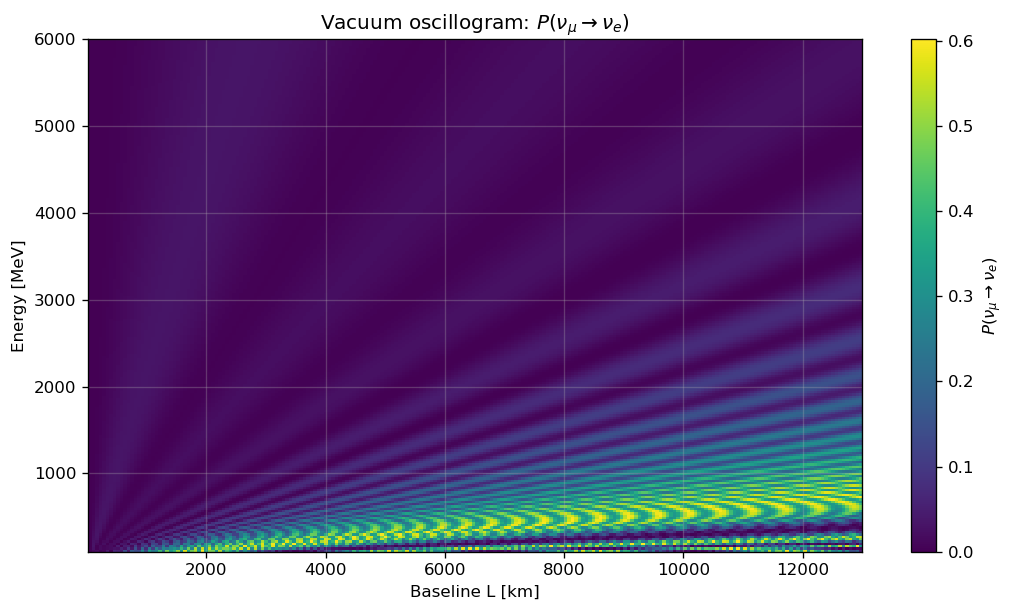

v:\output\diagnostic\vacuum\diagnostic1_fig6_oscillogram.png
P(mu->e) range over the L-E grid: [0.0000, 0.6020]


In [17]:
L_grid = torch.linspace(10.0, 13000.0, 220, device=ctx.device, dtype=ctx.dtype)
E_osc_grid = torch.linspace(100.0, 6000.0, 220, device=ctx.device, dtype=ctx.dtype)

L_mesh = L_grid[None, :]
E_mesh = E_osc_grid[:, None]
P_mesh = vacuum_probability_state(initial_mu, oscillation, E_mesh, L_mesh, massbasis=False, context=ctx)
P_mu_to_e = to_numpy(P_mesh[..., 0])

fig, ax = plt.subplots(figsize=(9.0, 5.2))
image = ax.imshow(
    P_mu_to_e,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    extent=[float(L_grid[0]), float(L_grid[-1]), float(E_osc_grid[0]), float(E_osc_grid[-1])],
    cmap="viridis",
    vmin=0.0,
    vmax=float(np.max(P_mu_to_e)),
)
ax.set_xlabel("Baseline L [km]")
ax.set_ylabel("Energy [MeV]")
ax.set_title(r"Vacuum oscillogram: $P(\nu_\mu\to\nu_e)$")
fig.colorbar(image, ax=ax, label=r"$P(\nu_\mu\to\nu_e)$")

fig.tight_layout()
save_and_show("diagnostic1_fig6_oscillogram.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"P(mu->e) range over the L-E grid: [{float(P_mu_to_e.min()):.4f}, {float(P_mu_to_e.max()):.4f}]")

## 7. Transition Probability Matrix Structure

`vacuum_probability_transition` returns the full $|S_{\alpha\beta}|^2$ transition matrix
at a representative $(E,L)$. Unitarity guarantees both rows and columns sum to
exactly 1 -- a stronger structural constraint than the Earth matter case,
where only rows sum to 1 (columns are only exactly conserved in vacuum).

**Expected results:** both row sums and column sums equal 1 to machine
precision.

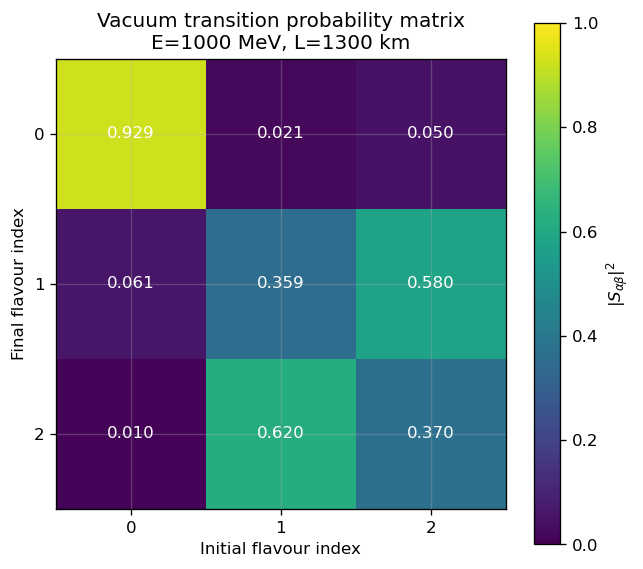

v:\output\diagnostic\vacuum\diagnostic1_fig7_transition_matrix.png
row sums    : [1. 1. 1.] (should all be 1.0)
column sums : [1. 1. 1.] (should all be 1.0)


In [18]:
P_matrix = vacuum_probability_transition(oscillation, torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype),
                               torch.tensor(1300.0, device=ctx.device, dtype=ctx.dtype), context=ctx)
P_matrix_np = to_numpy(P_matrix)

fig, ax = plt.subplots(figsize=(5.5, 5.0))
image = ax.imshow(P_matrix_np, vmin=0.0, vmax=1.0, cmap="viridis")
ax.set_title("Vacuum transition probability matrix\nE=1000 MeV, L=1300 km")
ax.set_xlabel("Initial flavour index")
ax.set_ylabel("Final flavour index")
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{P_matrix_np[i, j]:.3f}", ha="center", va="center", color="white")
fig.colorbar(image, ax=ax, label=r"$|S_{\alpha\beta}|^2$")

fig.tight_layout()
save_and_show("diagnostic1_fig7_transition_matrix.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f"row sums    : {P_matrix_np.sum(axis=1)} (should all be 1.0)")
print(f"column sums : {P_matrix_np.sum(axis=0)} (should all be 1.0)")

## 8. CP Violation and the Jarlskog Invariant

The CP-asymmetry $A_{CP}=P(\nu_\mu\to\nu_e)-P(\bar\nu_\mu\to\bar\nu_e)$ is
governed, to leading order in the standard three-flavour parametrization, by
the Jarlskog invariant
$J=\mathrm{Im}(U_{e1}U_{\mu2}U_{e2}^*U_{\mu1}^*)=\tfrac18\sin2\theta_{12}\sin2\theta_{13}\sin2\theta_{23}\cos\theta_{13}\sin\delta_{CP}$.

**Expected results:** the asymmetry should scale with $\sin\delta_{CP}$: it
should flip sign under $\delta_{CP}\to-\delta_{CP}$ and vanish at
$\delta_{CP}=0,\pi$.

In [ ]:
DELTA_SCAN = torch.linspace(0.0, 2.0 * math.pi, 25, device=ctx.device, dtype=ctx.dtype)
asymmetry_at_L1300 = []

for delta_val in DELTA_SCAN:
    osc_nu = make_oscillation(theta12=0.59, theta13=0.15, theta23=0.78, delta=float(delta_val),
                              DeltamSq21=7.42e-5, DeltamSq3l=2.517e-3, antinu=False, context=ctx)
    osc_anu = make_oscillation(theta12=0.59, theta13=0.15, theta23=0.78, delta=float(delta_val),
                               DeltamSq21=7.42e-5, DeltamSq3l=2.517e-3, antinu=True, context=ctx)
    p_nu = vacuum_probability_state(initial_mu, osc_nu, torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype),
                    torch.tensor(1300.0, device=ctx.device, dtype=ctx.dtype), massbasis=False, context=ctx)
    p_anu = vacuum_probability_state(initial_mu, osc_anu, torch.tensor(1000.0, device=ctx.device, dtype=ctx.dtype),
                     torch.tensor(1300.0, device=ctx.device, dtype=ctx.dtype), massbasis=False, context=ctx)
    asymmetry_at_L1300.append(float(p_nu[0] - p_anu[0]))

fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.plot(to_numpy(DELTA_SCAN), asymmetry_at_L1300, marker="o", ms=3)
ax.axhline(0.0, color="gray", lw=0.8)
ax.set_xlabel(r"CP phase $\delta_{CP}$ [rad]")
ax.set_ylabel(r"$P(\nu_\mu\to\nu_e)-P(\bar\nu_\mu\to\bar\nu_e)$")
ax.set_title("CP asymmetry vs delta_CP at E=1000 MeV, L=1300 km")

fig.tight_layout()
save_and_show("diagnostic1_fig8_cp_asymmetry_vs_delta.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

theta12, theta13, theta23 = 0.59, 0.15, 0.78
J_max = 0.125 * math.sin(2 * theta12) * math.sin(2 * theta13) * math.sin(2 * theta23) * math.cos(theta13)
print(f"Jarlskog prefactor (max |J| at delta=pi/2): {J_max:.5f}")
print(f"Asymmetry at delta=0      : {asymmetry_at_L1300[0]:.3e}")
print(f"Asymmetry at delta=pi (idx {len(DELTA_SCAN)//2}): {asymmetry_at_L1300[len(DELTA_SCAN)//2]:.3e}")

## 9. Vacuum Flux from Probability

`vacuum_flux_state` applies a flux normalization on top of `vacuum_probability_state`. The two input
conventions of Section 0.3 behave very differently under a baseline scan:

- **Mass basis** (incoherent weights $w_i$): mass eigenstates are the vacuum
  Hamiltonian's own stationary states, so an *incoherent* population mixture
  never oscillates. Concretely, $S U = U\,\mathrm{diag}(\text{phase})\,U^\dagger U
  = U\,\mathrm{diag}(\text{phase})$, so $|(SU)_{\alpha i}|^2=|U_{\alpha i}|^2$
  exactly, independent of $L$ and $E$ (the phase factors have unit modulus).
  A flat mass-basis flux/probability curve vs baseline is therefore the
  **correct physical result, not a bug** -- verified numerically below.
- **Flavour basis** (coherent amplitude $\psi$): the interference between mass
  eigenstates with different phases is exactly what produces oscillation, so
  $P_\alpha(L)=|(S\psi)_\alpha|^2$ genuinely varies with $L$.

The grid below uses the coherent case (initial $\nu_\mu$, matching Section 4)
to show the full chain: the complex evolved amplitude
(`vacuum_evolved_state`, real and imaginary parts, top row), the resulting
probability (`vacuum_probability_state`, bottom-left), and the resulting flux (`vacuum_flux_state`,
bottom-right).

**Expected results:** the mass-basis check should show a flux range at or
near machine precision across the baseline scan; the coherent-case panels
should all show the same $L$-dependent oscillation pattern, with the flux
panel equal to the probability panel scaled by `FLUX_NORMALIZATION`.

mass-basis flux per-flavour range across the baseline scan: 7.276e-11 (expected: ~0, confirms it is constant by construction)


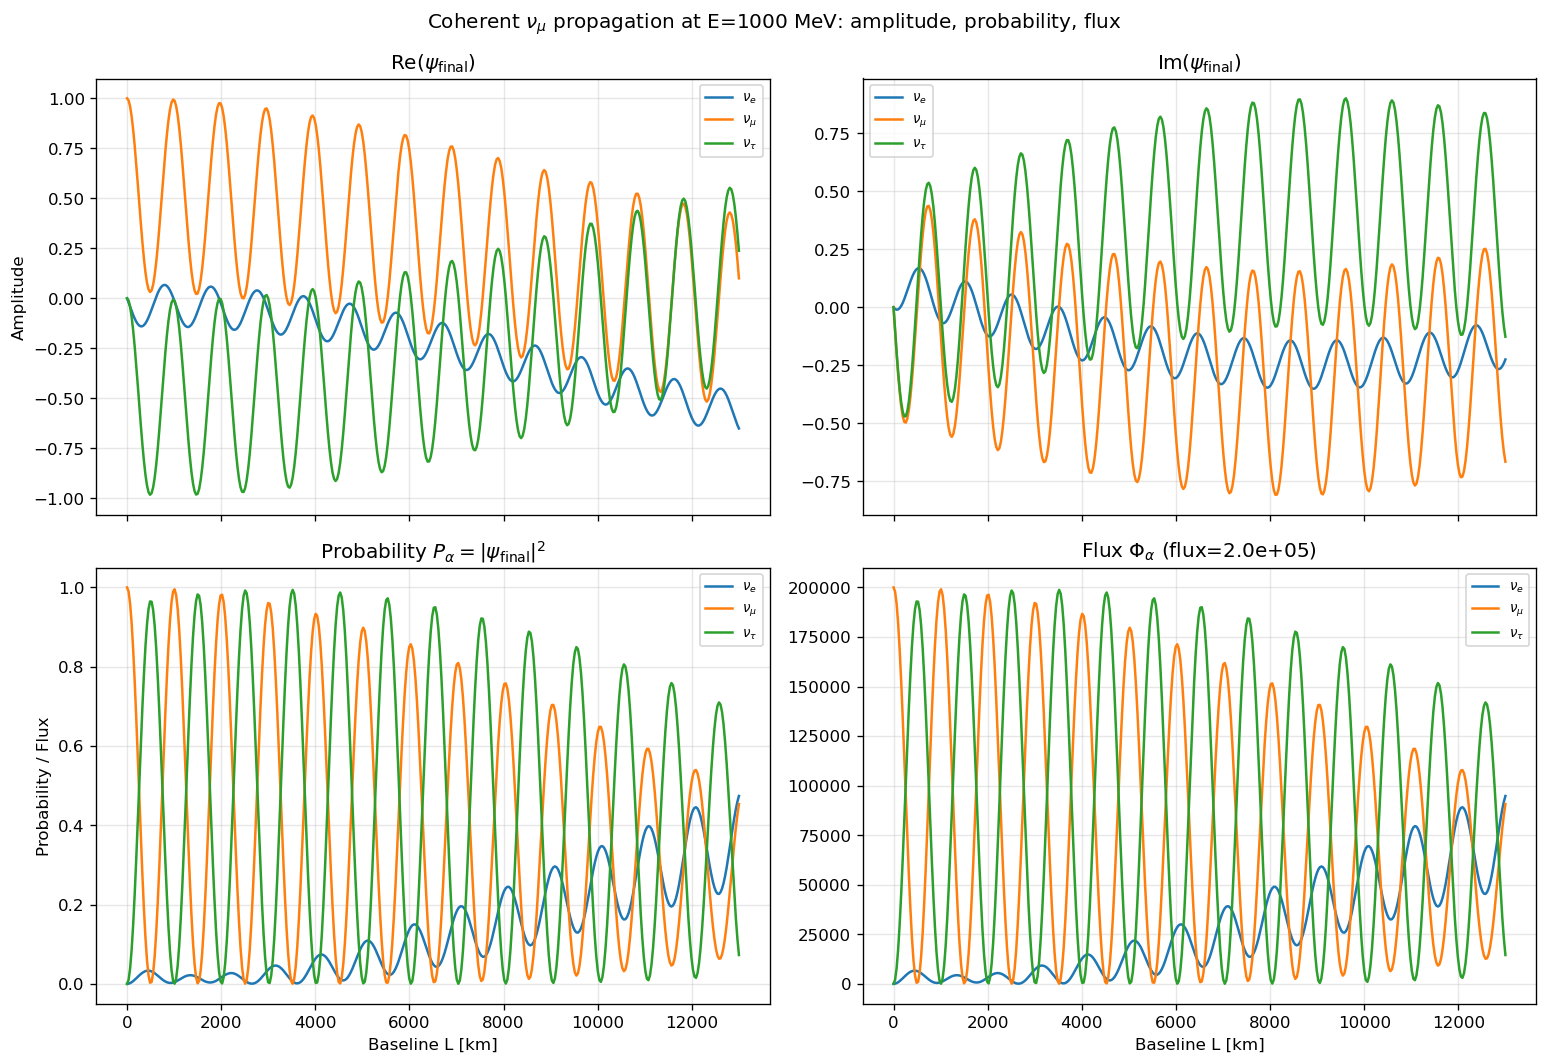

v:\output\diagnostic\vacuum\diagnostic1_fig9_vacuum_flux_vs_baseline.png
max |sum_alpha flux - flux_normalization| (coherent) : 1.455e-10
max ||amplitude|^2 - probability|                     : 0.000e+00


In [20]:
MASS_WEIGHTS = torch.tensor([0.55, 0.30, 0.15], device=ctx.device, dtype=ctx.dtype)
FLUX_NORMALIZATION = 2.0e5

flux_vs_L_massbasis = vacuum_flux_state(MASS_WEIGHTS, oscillation, torch.tensor(E_FIXED, device=ctx.device, dtype=ctx.dtype),
                                   baselines, flux=FLUX_NORMALIZATION, massbasis=True, context=ctx)
# Range *per flavour* across the baseline scan (not the much larger spread
# *between* flavours, which is physical and irrelevant to this check).
per_flavour_range = flux_vs_L_massbasis.max(dim=0).values - flux_vs_L_massbasis.min(dim=0).values
massbasis_flatness = float(per_flavour_range.max())
print(f"mass-basis flux per-flavour range across the baseline scan: {massbasis_flatness:.3e} (expected: ~0, confirms it is constant by construction)")

evolved_amplitude = vacuum_evolved_state(initial_mu, oscillation, torch.tensor(E_FIXED, device=ctx.device, dtype=ctx.dtype),
                                          baselines, context=ctx)
P_vs_L_coherent = vacuum_probability_state(initial_mu, oscillation, torch.tensor(E_FIXED, device=ctx.device, dtype=ctx.dtype),
                           baselines, massbasis=False, context=ctx)
flux_vs_L_coherent = vacuum_flux_state(initial_mu, oscillation, torch.tensor(E_FIXED, device=ctx.device, dtype=ctx.dtype),
                                  baselines, flux=FLUX_NORMALIZATION, massbasis=False, context=ctx)

fig, axes = plt.subplots(2, 2, figsize=(13.0, 9.0), sharex=True)

for idx, label in enumerate(FLAVOUR_LABELS):
    axes[0, 0].plot(to_numpy(baselines), to_numpy(evolved_amplitude[:, idx].real), label=label)
    axes[0, 1].plot(to_numpy(baselines), to_numpy(evolved_amplitude[:, idx].imag), label=label)
    axes[1, 0].plot(to_numpy(baselines), to_numpy(P_vs_L_coherent[:, idx]), label=label)
    axes[1, 1].plot(to_numpy(baselines), to_numpy(flux_vs_L_coherent[:, idx]), label=label)

axes[0, 0].set_title(r"Re$(\psi_{\rm final})$")
axes[0, 1].set_title(r"Im$(\psi_{\rm final})$")
axes[1, 0].set_title(r"Probability $P_\alpha=|\psi_{\rm final}|^2$")
axes[1, 1].set_title(rf"Flux $\Phi_\alpha$ (flux={FLUX_NORMALIZATION:.1e})")

axes[0, 0].set_ylabel("Amplitude")
axes[1, 0].set_ylabel("Probability / Flux")
for ax in axes[1, :]:
    ax.set_xlabel("Baseline L [km]")
for ax in axes.flat:
    ax.legend(fontsize=8)

fig.suptitle(rf"Coherent $\nu_\mu$ propagation at E={E_FIXED:.0f} MeV: amplitude, probability, flux")
fig.tight_layout()
save_and_show("diagnostic1_fig9_vacuum_flux_vs_baseline.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

flux_sum_check = float(torch.max(torch.abs(flux_vs_L_coherent.sum(dim=-1) - FLUX_NORMALIZATION)))
amplitude_consistency = float(torch.max(torch.abs(torch.abs(evolved_amplitude) ** 2 - P_vs_L_coherent)))
print(f"max |sum_alpha flux - flux_normalization| (coherent) : {flux_sum_check:.3e}")
print(f"max ||amplitude|^2 - probability|                     : {amplitude_consistency:.3e}")

## 10. Validation against Legacy Peanuts

`vacuum_probability_state` is compared against `peanuts.vacuum.Pvacuum` for a flavour-basis
state, a different flavour-basis state, and a mass-basis weight vector, using
the ready-made helper `tpeanuts.medium.vacuum.validation.compare_vacuum_probability_state_with_legacy`.

**Expected results:** agreement at the $10^{-10}$ level for all three cases.
The raw complex-amplitude comparison (`vacuum_evolved_state` vs legacy
`vacuum_evolved_state`) is *not* shown here because the legacy function itself
has an argument-order bug in its call to `Upert` (confirmed by reading
`peanuts/vacuum.py`): `vacuum_evolved_state` calls
`Upert(..., 0, l, ...)` while the validated `Pvacuum` calls
`Upert(..., l, 0, ...)` for the same baseline. This is documented as a
`strict=True` `xfail` in `test2_probability.py` rather than silently ignored.

In [21]:
legacy_cases = [
    ("flavour nu_e", [1.0, 0.0, 0.0], False, 900.0, 295.0),
    ("flavour nu_mu", [0.0, 1.0, 0.0], False, 2500.0, 1300.0),
    ("mass weights", [0.20, 0.30, 0.50], True, 5000.0, 12000.0),
]

print(f"{'case':>14} | {'max |torch - legacy|':>22}")
legacy_max_errors = []
for label, state, massbasis, energy, baseline in legacy_cases:
    result = legacy_validation.compare_vacuum_probability_state_with_legacy(state, oscillation, energy, baseline, massbasis=massbasis, context=ctx)
    legacy_max_errors.append(result["max_abs"])
    print(f"{label:>14} | {result['max_abs']:>22.3e}")

print(f"\nGlobal max error vs legacy Pvacuum: {max(legacy_max_errors):.3e}")

          case |   max |torch - legacy|
  flavour nu_e |              1.805e-11
 flavour nu_mu |              4.079e-11
  mass weights |              2.776e-15

Global max error vs legacy Pvacuum: 4.079e-11


## 11. Summary

In [22]:
print("Summary - Vacuum Diagnostic 1: Propagation and Flux")
print("-" * 60)
print(f"max unitarity error              : {float(torch.max(unitarity_error)):.3e}")
print(f"max scale-invariance error        : {scale_invariance_error:.3e}")
print(f"max |sum_alpha P - 1| (baseline)  : {row_sum_err:.3e}")
print(f"max |P(nu)-P(antinu)| at delta=0  : {float(torch.max(torch.abs(P_nu_cp0 - P_anu_cp0))):.3e}")
print(f"max |sum flux - normalization|    : {flux_sum_check:.3e}")
print(f"max error vs legacy Pvacuum       : {max(legacy_max_errors):.3e}")
print()
print("Pytest companions: tpeanuts.medium.vacuum.test.test1_evolutor, test2_probability, test3_flux")

Summary - Vacuum Diagnostic 1: Propagation and Flux
------------------------------------------------------------
max unitarity error              : 5.551e-16
max scale-invariance error        : 7.850e-17
max |sum_alpha P - 1| (baseline)  : 8.882e-16
max |P(nu)-P(antinu)| at delta=0  : 0.000e+00
max |sum flux - normalization|    : 1.455e-10
max error vs legacy Pvacuum       : 4.079e-11

Pytest companions: tpeanuts.medium.vacuum.test.test1_evolutor, test2_probability, test3_flux
